In [2]:

!pip install pandas numpy matplotlib seaborn scikit-learn tensorflow sqlalchemy schedule openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import sqlite3
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import warnings
warnings.filterwarnings('ignore')

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

print("✅ All libraries installed and Drive mounted!")

Mounted at /content/drive
✅ All libraries installed and Drive mounted!


In [3]:
# Generate Synthetic Traffic & Accident Data
np.random.seed(42)

# Create 30 days of hourly data
hours = pd.date_range('2024-01-01', '2024-01-31 23:00:00', freq='H')
n = len(hours)

# Simulate 5 different locations
locations = [f"Intersection_{i}" for i in range(1, 6)]

data = []
for loc in locations:
    # Base patterns
    hour_of_day = hours.hour
    day_of_week = hours.dayofweek

    # Traffic pattern: rush hours (7-9 AM, 4-7 PM) have higher volume
    traffic_base = 1000 + 500 * np.sin(2 * np.pi * hour_of_day / 24)
    rush_hour_boost = np.where((hour_of_day >= 7) & (hour_of_day <= 9), 800,
                               np.where((hour_of_day >= 16) & (hour_of_day <= 19), 700, 0))

    # Weather effects
    rain_intensity = np.random.uniform(0, 15, n)  # mm per hour
    is_weekend = (day_of_week >= 5).astype(int)

    # Traffic volume (vehicles per hour)
    traffic_volume = traffic_base + rush_hour_boost - (rain_intensity * 20) - (is_weekend * 200)
    traffic_volume = np.maximum(traffic_volume, 100)  # minimum 100 vehicles

    # Accident probability (depends on traffic, rain, rush hour)
    accident_prob = 0.01 + (traffic_volume / 5000) * 0.05 + (rain_intensity / 30) * 0.1
    accident_prob += rush_hour_boost / 5000
    accident_occurred = np.random.binomial(1, accident_prob)

    # Average speed (km/h) - inversely related to traffic and rain
    avg_speed = 50 - (traffic_volume / 5000) * 30 - (rain_intensity / 10) * 5
    avg_speed = np.clip(avg_speed, 10, 80)

    for i in range(n):
        data.append({
            'timestamp': hours[i],
            'location': loc,
            'hour': hour_of_day[i],
            'day_of_week': day_of_week[i],
            'is_weekend': is_weekend[i],
            'rain_intensity_mm': rain_intensity[i],
            'traffic_volume': traffic_volume[i],
            'avg_speed_kmh': avg_speed[i],
            'accident_occurred': accident_occurred[i]
        })

df = pd.DataFrame(data)
print(f"✅ Generated {len(df)} records")
print(df.head())

✅ Generated 3720 records
            timestamp        location  hour  day_of_week  is_weekend  \
0 2024-01-01 00:00:00  Intersection_1     0            0           0   
1 2024-01-01 01:00:00  Intersection_1     1            0           0   
2 2024-01-01 02:00:00  Intersection_1     2            0           0   
3 2024-01-01 03:00:00  Intersection_1     3            0           0   
4 2024-01-01 04:00:00  Intersection_1     4            0           0   

   rain_intensity_mm  traffic_volume  avg_speed_kmh  accident_occurred  
0           5.618102      887.637964      41.865121                  0  
1          14.260715      844.195231      37.804471                  0  
2          10.979909     1030.401817      38.327635                  0  
3           8.979877     1173.955845      38.466326                  0  
4           2.340280     1386.207110      40.512618                  0  


In [4]:
print("Initial shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())

# No missing values in synthetic data, but if using real data:
df_clean = df.dropna()
df_clean = df_clean.drop_duplicates()

# Create additional features
df_clean['time_of_day'] = pd.cut(df_clean['hour'],
                                 bins=[0, 6, 12, 18, 24],
                                 labels=['Night', 'Morning', 'Afternoon', 'Evening'])

df_clean['accident_severity'] = np.where(df_clean['accident_occurred'] == 1,
                                         np.random.choice(['Low', 'Medium', 'High'], size=len(df_clean)),
                                         'None')

# Save to SQLite
conn = sqlite3.connect('/content/drive/MyDrive/traffic_data.db')
df_clean.to_sql('traffic_data', conn, if_exists='replace', index=False)

print(f"✅ Cleaned data shape: {df_clean.shape}")
print(df_clean[['timestamp', 'location', 'traffic_volume', 'accident_occurred']].head())

Initial shape: (3720, 9)

Missing values:
 timestamp            0
location             0
hour                 0
day_of_week          0
is_weekend           0
rain_intensity_mm    0
traffic_volume       0
avg_speed_kmh        0
accident_occurred    0
dtype: int64
✅ Cleaned data shape: (3720, 11)
            timestamp        location  traffic_volume  accident_occurred
0 2024-01-01 00:00:00  Intersection_1      887.637964                  0
1 2024-01-01 01:00:00  Intersection_1      844.195231                  0
2 2024-01-01 02:00:00  Intersection_1     1030.401817                  0
3 2024-01-01 03:00:00  Intersection_1     1173.955845                  0
4 2024-01-01 04:00:00  Intersection_1     1386.207110                  0


In [5]:
report = {
    'total_records': len(df_clean),
    'locations': df_clean['location'].nunique(),
    'date_range': f"{df_clean['timestamp'].min()} to {df_clean['timestamp'].max()}",
    'accident_rate': f"{df_clean['accident_occurred'].mean()*100:.2f}%",
    'avg_traffic_volume': f"{df_clean['traffic_volume'].mean():.0f}",
    'avg_speed': f"{df_clean['avg_speed_kmh'].mean():.1f} km/h"
}

for key, value in report.items():
    print(f"{key}: {value}")

total_records: 3720
locations: 5
date_range: 2024-01-01 00:00:00 to 2024-01-31 23:00:00
accident_rate: 9.09%
avg_traffic_volume: 1016
avg_speed: 40.2 km/h


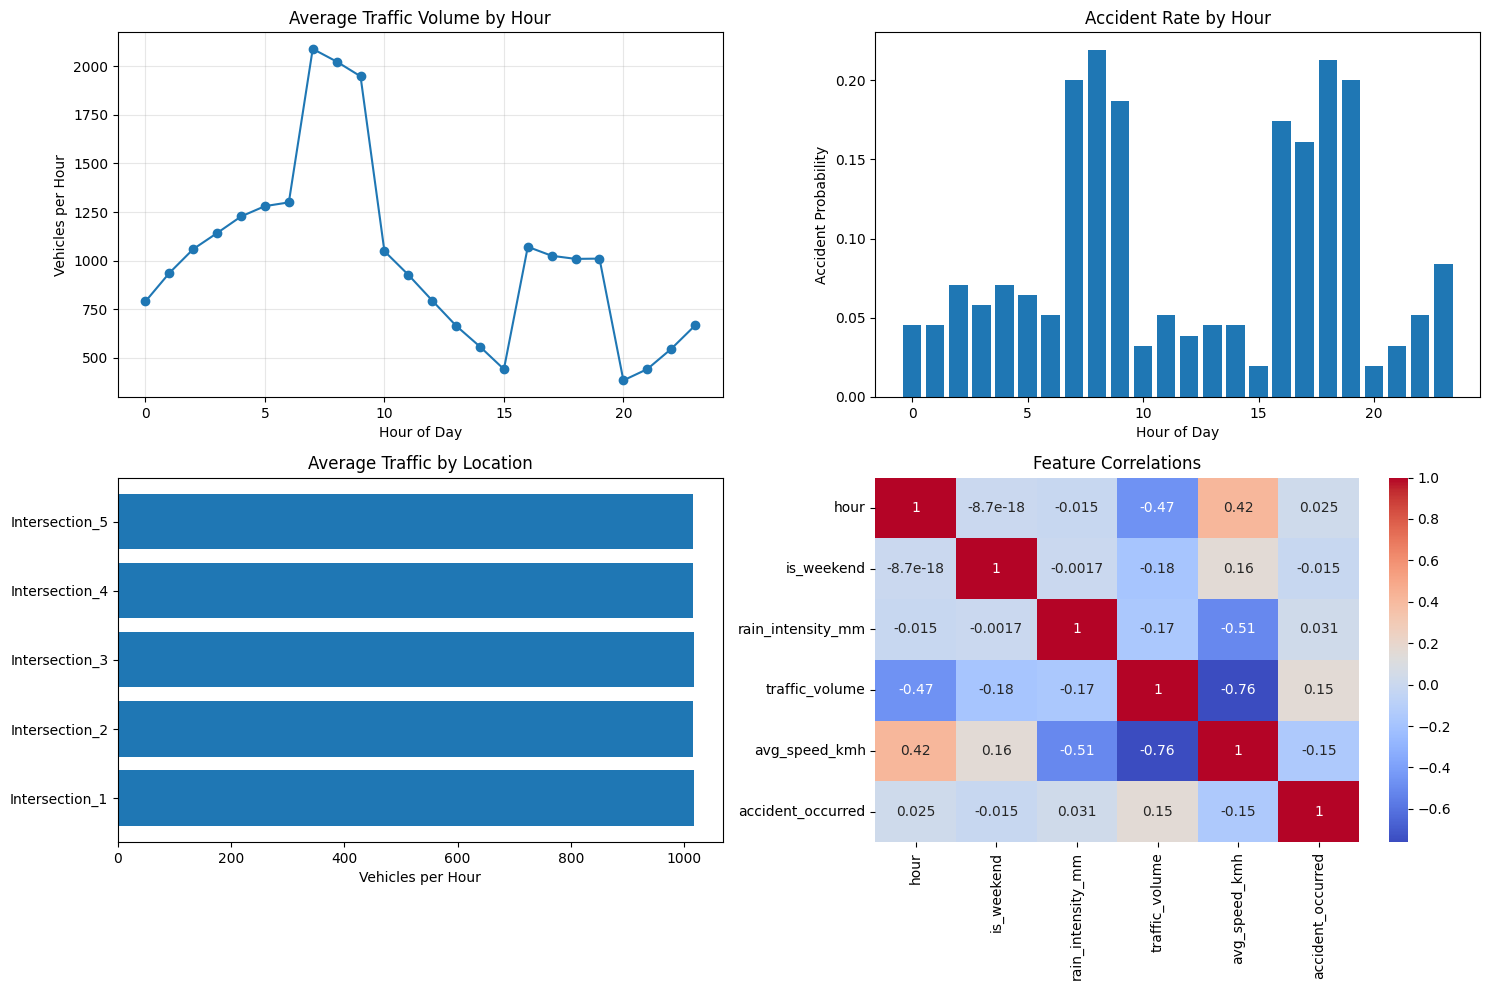

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Traffic by hour
hourly_traffic = df_clean.groupby('hour')['traffic_volume'].mean()
axes[0,0].plot(hourly_traffic.index, hourly_traffic.values, marker='o')
axes[0,0].set_title('Average Traffic Volume by Hour')
axes[0,0].set_xlabel('Hour of Day')
axes[0,0].set_ylabel('Vehicles per Hour')
axes[0,0].grid(True, alpha=0.3)

# Accident rate by hour
accident_by_hour = df_clean.groupby('hour')['accident_occurred'].mean()
axes[0,1].bar(accident_by_hour.index, accident_by_hour.values)
axes[0,1].set_title('Accident Rate by Hour')
axes[0,1].set_xlabel('Hour of Day')
axes[0,1].set_ylabel('Accident Probability')

# Traffic by location
location_traffic = df_clean.groupby('location')['traffic_volume'].mean()
axes[1,0].barh(location_traffic.index, location_traffic.values)
axes[1,0].set_title('Average Traffic by Location')
axes[1,0].set_xlabel('Vehicles per Hour')

# Correlation heatmap
numeric_cols = ['hour', 'is_weekend', 'rain_intensity_mm', 'traffic_volume', 'avg_speed_kmh', 'accident_occurred']
corr = df_clean[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', ax=axes[1,1])
axes[1,1].set_title('Feature Correlations')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/eda_traffic_analysis.png', dpi=150)
plt.show()

In [7]:
# @title 3.2 Statistical Analysis
from scipy import stats

# T-test: Traffic speed on days with vs without accidents
with_accident = df_clean[df_clean['accident_occurred'] == 1]['avg_speed_kmh']
without_accident = df_clean[df_clean['accident_occurred'] == 0]['avg_speed_kmh']
t_stat, p_value = stats.ttest_ind(with_accident, without_accident)

print("📊 Statistical Analysis Results:")
print(f"1. T-test (Speed with vs without accidents):")
print(f"   T-statistic: {t_stat:.3f}, P-value: {p_value:.5f}")
if p_value < 0.05:
    print("   ✅ Significant difference found (p < 0.05)")

# Chi-square: Accident occurrence by weekend
contingency = pd.crosstab(df_clean['is_weekend'], df_clean['accident_occurred'])
chi2, p, dof, expected = stats.chi2_contingency(contingency)
print(f"\n2. Chi-square test (Weekend vs Accident):")
print(f"   Chi2: {chi2:.3f}, P-value: {p:.5f}")

# Correlation analysis
corr_traffic_accident = df_clean['traffic_volume'].corr(df_clean['accident_occurred'])
print(f"\n3. Correlation between traffic volume and accidents: {corr_traffic_accident:.3f}")

📊 Statistical Analysis Results:
1. T-test (Speed with vs without accidents):
   T-statistic: -9.540, P-value: 0.00000
   ✅ Significant difference found (p < 0.05)

2. Chi-square test (Weekend vs Accident):
   Chi2: 0.769, P-value: 0.38057

3. Correlation between traffic volume and accidents: 0.154


In [8]:
# @title 4.1 Feature Engineering
# Prepare features for ML
features = ['hour', 'is_weekend', 'rain_intensity_mm', 'traffic_volume', 'avg_speed_kmh']
X = df_clean[features]
y = df_clean['accident_occurred']

# Add location as categorical (one-hot encoding)
location_dummies = pd.get_dummies(df_clean['location'], prefix='loc')
X = pd.concat([X, location_dummies], axis=1)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features for neural network
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 2976 samples
Test set: 744 samples


🌲 RANDOM FOREST RESULTS
Accuracy: 0.906

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.99      0.95       678
           1       0.00      0.00      0.00        66

    accuracy                           0.91       744
   macro avg       0.46      0.50      0.48       744
weighted avg       0.83      0.91      0.87       744


Top 10 Most Important Features:
              feature  importance
4       avg_speed_kmh    0.273643
3      traffic_volume    0.273133
2   rain_intensity_mm    0.247157
0                hour    0.116063
9  loc_Intersection_5    0.018032
1          is_weekend    0.016883
5  loc_Intersection_1    0.014682
7  loc_Intersection_3    0.014042
6  loc_Intersection_2    0.014037
8  loc_Intersection_4    0.012328


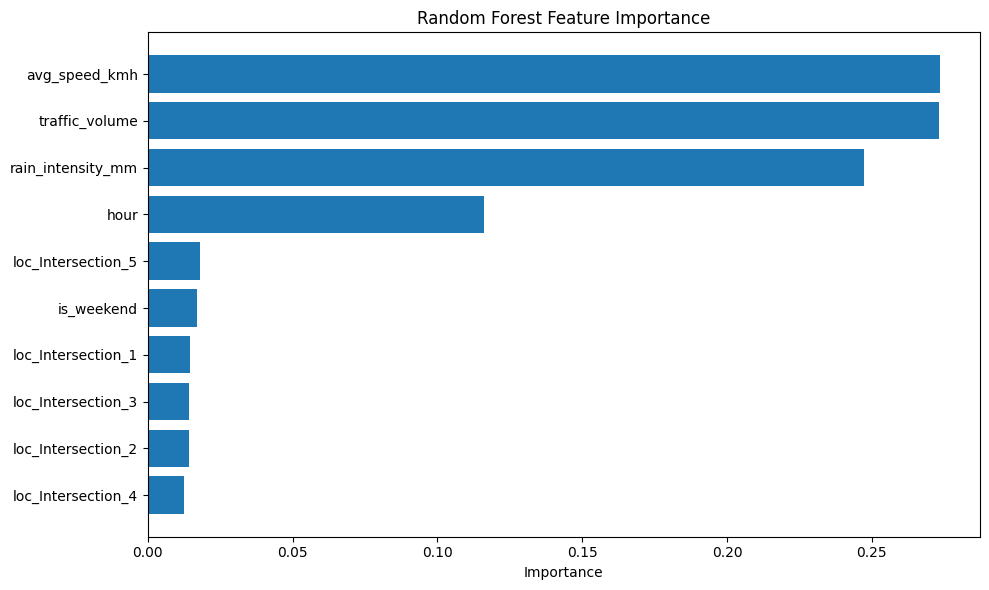

In [9]:
# @title 4.2 Random Forest Classifier (Accident Risk)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluation
print("🌲 RANDOM FOREST RESULTS")
print("="*50)
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# Feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10))

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'][:10], feature_importance['importance'][:10])
plt.xlabel('Importance')
plt.title('Random Forest Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/feature_importance.png')
plt.show()

Epoch 1/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - loss: 0.9803 - mae: 0.7469 - val_loss: 0.8737 - val_mae: 0.6980
Epoch 2/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.8345 - mae: 0.6937 - val_loss: 0.4665 - val_mae: 0.5608
Epoch 3/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.7561 - mae: 0.6743 - val_loss: 0.6533 - val_mae: 0.6247
Epoch 4/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.6539 - mae: 0.6340 - val_loss: 0.5312 - val_mae: 0.5640
Epoch 5/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.5324 - mae: 0.5831 - val_loss: 0.3658 - val_mae: 0.4978
Epoch 6/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.4789 - mae: 0.5601 - val_loss: 0.3552 - val_mae: 0.4902
Epoch 7/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.4246 - mae: 0.5240 - val_loss: 0.3232 - val_mae: 0.4867
Epoch 8/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.3553 - mae: 0.4860 - val_loss: 0.3395 - val_mae: 0.4914
Epoch 9/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.456

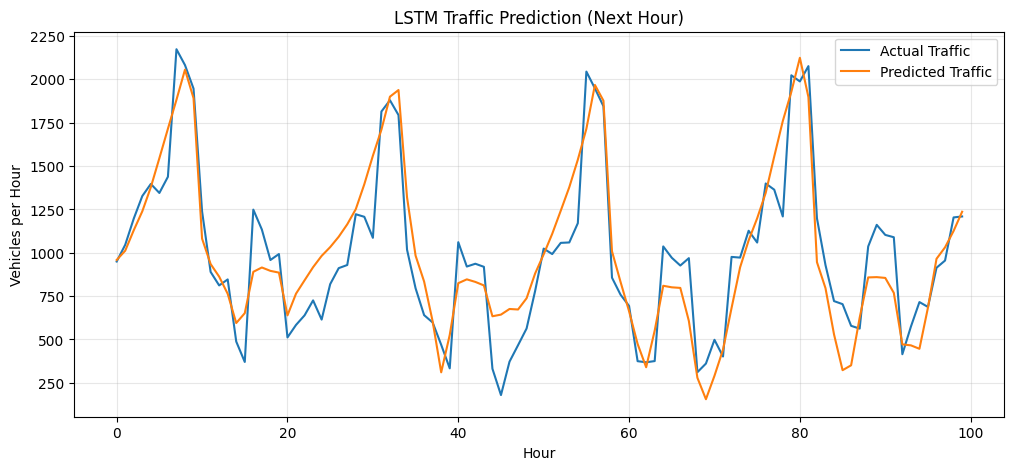

In [10]:
# @title 4.3 LSTM for Traffic Volume Prediction (TensorFlow)

# Prepare time series data
def create_sequences(data, sequence_length=24):
    X_seq, y_seq = [], []
    for i in range(len(data) - sequence_length):
        X_seq.append(data[i:i+sequence_length])
        y_seq.append(data[i+sequence_length])
    return np.array(X_seq), np.array(y_seq)

# Prepare traffic data for one location
location_data = df_clean[df_clean['location'] == 'Intersection_1'].copy()
location_data = location_data.sort_values('timestamp')
traffic_values = location_data['traffic_volume'].values

# Normalize
traffic_normalized = (traffic_values - traffic_values.mean()) / traffic_values.std()

# Create sequences
sequence_length = 24  # Use past 24 hours to predict next hour
X_lstm, y_lstm = create_sequences(traffic_normalized, sequence_length)

# Reshape for LSTM [samples, timesteps, features]
X_lstm = X_lstm.reshape((X_lstm.shape[0], X_lstm.shape[1], 1))

# Split
split = int(0.8 * len(X_lstm))
X_train_lstm, X_test_lstm = X_lstm[:split], X_lstm[split:]
y_train_lstm, y_test_lstm = y_lstm[:split], y_lstm[split:]

# Build LSTM model
lstm_model = keras.Sequential([
    layers.LSTM(64, activation='relu', return_sequences=True, input_shape=(sequence_length, 1)),
    layers.LSTM(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train
history = lstm_model.fit(
    X_train_lstm, y_train_lstm,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# Evaluate
test_loss, test_mae = lstm_model.evaluate(X_test_lstm, y_test_lstm, verbose=0)
print(f"\n🧠 LSTM RESULTS")
print("="*50)
print(f"Test MAE (normalized): {test_mae:.3f}")

# Denormalize predictions
y_pred_lstm = lstm_model.predict(X_test_lstm)
y_test_denorm = y_test_lstm * traffic_values.std() + traffic_values.mean()
y_pred_denorm = y_pred_lstm.flatten() * traffic_values.std() + traffic_values.mean()

print(f"Actual MAE (vehicles): {np.mean(np.abs(y_test_denorm - y_pred_denorm)):.1f}")

# Plot predictions
plt.figure(figsize=(12, 5))
plt.plot(y_test_denorm[:100], label='Actual Traffic')
plt.plot(y_pred_denorm[:100], label='Predicted Traffic')
plt.xlabel('Hour')
plt.ylabel('Vehicles per Hour')
plt.title('LSTM Traffic Prediction (Next Hour)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('/content/drive/MyDrive/lstm_predictions.png')
plt.show()

In [13]:
# @title 7.1 Schedule Regular Updates (Simulated Real-time)
import schedule
import time
from threading import Thread

def update_data():
    """Simulate new data arrival and model retraining"""
    print(f"\n🔄 Updating data at {datetime.now()}")

    # Generate new hourly data point for each location
    new_data = []
    for loc in locations:
        new_record = {
            'timestamp': datetime.now(),
            'location': loc,
            'hour': datetime.now().hour,
            'day_of_week': datetime.now().weekday(),
            'is_weekend': 1 if datetime.now().weekday() >= 5 else 0,
            'rain_intensity_mm': np.random.uniform(0, 10),
            'traffic_volume': np.random.normal(1500, 300),
            'avg_speed_kmh': np.random.normal(45, 10),
            'accident_occurred': np.random.binomial(1, 0.05)
        }
        new_data.append(new_record)

    df_new = pd.DataFrame(new_data)
    # Append to existing data (in real scenario, you'd save to database)
    print(f"✅ Added {len(df_new)} new records")
    return df_new

# For Colab, we'll run once as demo
print("🕐 Simulating automated pipeline...")
update_data()

# To run continuously (uncomment - will run until interrupted)
# def run_scheduler():
#     schedule.every(1).hours.do(update_data)
#     while True:
#         schedule.run_pending()
#         time.sleep(60)
#
# scheduler_thread = Thread(target=run_scheduler, daemon=True)
# scheduler_thread.start()

🕐 Simulating automated pipeline...

🔄 Updating data at 2026-05-08 03:06:20.460725
✅ Added 5 new records


,timestamp,location,hour,day_of_week,is_weekend,rain_intensity_mm,traffic_volume,avg_speed_kmh,accident_occurred
0,2026-05-08 03:06:20.460763,Intersection_1,3,4,0,1.347978,1481.411098,53.625709,0
1,2026-05-08 03:06:20.460855,Intersection_2,3,4,0,9.281061,854.388744,49.448337,0
2,2026-05-08 03:06:20.460879,Intersection_3,3,4,0,4.428502,1846.048063,35.619771,0
3,2026-05-08 03:06:20.460898,Intersection_4,3,4,0,7.917162,1658.755074,48.995811,0
4,2026-05-08 03:06:20.460916,Intersection_5,3,4,0,3.624314,1689.046376,60.014858,0
